<a href="https://colab.research.google.com/github/jornalistadno/TESTE---demanda-creche/blob/main/Web%20Scraper%20demanda%20creche%202022-2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import re


In [2]:
URL_PAGINA = "https://educacao.sme.prefeitura.sp.gov.br/acesso-a-informacao/demanda-escolar/"

resposta = requests.get(URL_PAGINA, timeout=30)

resposta.raise_for_status()

print("Página acessada com sucesso.")
print("Status:", resposta.status_code)


Página acessada com sucesso.
Status: 200


In [3]:
soup = BeautifulSoup(resposta.text, "html.parser")

links = soup.find_all("a")

print("Total de links encontrados:", len(links))


Total de links encontrados: 235


In [4]:
arquivos = []

for link in links:
    href = link.get("href")
    texto = link.get_text(" ", strip=True)

    if not href:
        continue

    url_arquivo = urljoin(URL_PAGINA, href)

    if url_arquivo.lower().endswith((".xls", ".xlsx")):
        arquivos.append({
            "texto": texto,
            "url": url_arquivo
        })

df_links = pd.DataFrame(arquivos)

print("Arquivos Excel encontrados:", len(df_links))


Arquivos Excel encontrados: 45


In [5]:
def extrair_ano(texto, url):
    resultado = re.search(r"\b(20\d{2})\b", texto)

    if resultado:
        return int(resultado.group(1))

    resultado = re.search(r"\b(20\d{2})\b", url)

    if resultado:
        return int(resultado.group(1))

    return pd.NA


In [6]:
df_links["ano"] = df_links.apply(
    lambda linha: extrair_ano(
        linha["texto"],
        linha["url"]
    ),
    axis=1
)

df_links["ano"] = pd.to_numeric(
    df_links["ano"],
    errors="coerce"
).astype("Int64")


In [7]:
ANOS_ANALISE = [2022, 2023, 2024, 2025]

df_analise = df_links[
    df_links["ano"].isin(ANOS_ANALISE)
].copy()

print("Arquivos selecionados:", len(df_analise))


Arquivos selecionados: 22


In [8]:
df_analise[["ano", "texto", "url"]]


,ano,texto,url
3,2025,XLS matrículas e demanda Fevereiro 2025,https://educacao.sme.prefeitura.sp.gov.br/wp-c...
4,2025,XLS matrículas e demanda Abril 2025,https://educacao.sme.prefeitura.sp.gov.br/wp-c...
5,2025,XLS matrículas e demanda Junho 2025,https://educacao.sme.prefeitura.sp.gov.br/wp-c...
6,2025,XLS matrículas e demanda Agosto 2025,https://educacao.sme.prefeitura.sp.gov.br/wp-c...
7,2025,XLS matrículas e demanda Outubro 2025,https://educacao.sme.prefeitura.sp.gov.br/wp-c...
8,2025,XLS matrículas e demanda Dezembro 2025,https://educacao.sme.prefeitura.sp.gov.br/wp-c...
9,2024,XLS matrículas e demanda Fevereiro 2024,https://educacao.sme.prefeitura.sp.gov.br/wp-c...
10,2024,XLS matrículas e demanda Abril 2024,https://educacao.sme.prefeitura.sp.gov.br/wp-c...
11,2024,XLS matrículas e demanda Junho 2024,https://educacao.sme.prefeitura.sp.gov.br/wp-c...
12,2024,XLS matrículas e demanda Agosto 2024,https://educacao.sme.prefeitura.sp.gov.br/wp-c...


In [9]:
df_analise["ano"].value_counts().sort_index()


,count
ano,
2022,4
2023,6
2024,6
2025,6


In [11]:
from pathlib import Path


In [12]:
PASTA_RAW = Path("data/raw")

PASTA_RAW.mkdir(parents=True, exist_ok=True)

print("Pasta criada:", PASTA_RAW)


Pasta criada: data/raw


In [13]:
for _, linha in df_analise.iterrows():
    ano = linha["ano"]
    texto = linha["texto"]
    url_arquivo = linha["url"]

    nome = f"{ano}_{texto}"
    nome = re.sub(r"[^\w\s-]", "", nome)
    nome = re.sub(r"\s+", "_", nome).strip("_")

    extensao = ".xlsx" if url_arquivo.lower().endswith(".xlsx") else ".xls"

    caminho = PASTA_RAW / f"{nome}{extensao}"

    resposta_arquivo = requests.get(url_arquivo, timeout=60)
    resposta_arquivo.raise_for_status()

    caminho.write_bytes(resposta_arquivo.content)

    print(f"Baixado: {caminho.name}")


Baixado: 2025_XLS_matrículas_e_demanda_Fevereiro_2025.xls
Baixado: 2025_XLS_matrículas_e_demanda_Abril_2025.xls
Baixado: 2025_XLS_matrículas_e_demanda_Junho_2025.xls
Baixado: 2025_XLS_matrículas_e_demanda_Agosto_2025.xls
Baixado: 2025_XLS_matrículas_e_demanda_Outubro_2025.xls
Baixado: 2025_XLS_matrículas_e_demanda_Dezembro_2025.xls
Baixado: 2024_XLS_matrículas_e_demanda_Fevereiro_2024.xls
Baixado: 2024_XLS_matrículas_e_demanda_Abril_2024.xls
Baixado: 2024_XLS_matrículas_e_demanda_Junho_2024.xls
Baixado: 2024_XLS_matrículas_e_demanda_Agosto_2024.xls
Baixado: 2024_XLS_matrículas_e_demanda_Outubro_2024.xls
Baixado: 2024_XLS_matrículas_e_demanda_Dezembro_2024.xls
Baixado: 2023_XLS_matrículas_e_demanda_Fevereiro_2023.xls
Baixado: 2023_XLS_matrículas_e_demanda_Abril_2023.xls
Baixado: 2023_XLS_matrículas_e_demanda_Junho_2023.xls
Baixado: 2023_XLS_matrículas_e_demanda_Agosto_2023.xls
Baixado: 2023_XLS_matrículas_e_demanda_Outubro_2023.xls
Baixado: 2023_XLS_matrículas_e_demanda_Dezembro_2023.xl

In [14]:
arquivos_baixados = list(PASTA_RAW.glob("*"))

print("Arquivos baixados:", len(arquivos_baixados))


Arquivos baixados: 22


In [15]:
arquivo_teste = sorted(PASTA_RAW.glob("2022_*"))[0]

print("Arquivo escolhido:")
print(arquivo_teste.name)


Arquivo escolhido:
2022_XLS_matrículas_e_demanda_Dezembro_2022.xls


In [16]:
df_teste = pd.read_excel(arquivo_teste)

print("Linhas:", df_teste.shape[0])
print("Colunas:", df_teste.shape[1])

df_teste.head(10)


Linhas: 101
Colunas: 23


,Distrito,Matrículas,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Matrícula em Processo,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,NaN,Creche,Pré Escola,Ens. Fund.I,Ens. Fund.II,EJA I,EJA II,Ens. Médio,Ed. Prof.,Creche,...,Creche (3),Creche Total,Pré Escola (1),Pré Escola (2),Pré Escola (3),Pré Escola Total,Ens. Fund.I,Ens. Fund.II,EJA I,EJA II
1,AGUA RASA,1250,767,937,884,0,67,0,0,4,...,2,2,0,0,0,0,0,0,0,0
2,ALTO DE PINHEIROS,338,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,ANHANGUERA,2956,1751,2977,2431,51,292,0,0,2,...,4,4,0,0,0,0,0,0,0,0
4,ARICANDUVA,1585,730,1199,1182,28,115,0,0,13,...,10,10,0,0,0,0,0,0,0,0
5,ARTUR ALVIM,2867,2057,2425,2042,0,36,0,0,7,...,4,4,0,0,0,0,0,0,0,0
6,BARRA FUNDA,276,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
7,BELA VISTA,1270,553,462,359,0,117,0,0,2,...,10,10,0,0,0,0,0,0,0,0
8,BELEM,1221,786,526,380,0,0,0,0,7,...,17,17,0,0,0,0,0,0,0,0
9,BOM RETIRO,1361,706,0,0,0,0,0,0,4,...,4,4,0,0,0,0,0,0,0,0


In [17]:
print("Colunas encontradas:")

for i, coluna in enumerate(df_teste.columns):
    print(i, "→", repr(coluna))


Colunas encontradas:
0 → 'Distrito'
1 → 'Matrículas'
2 → 'Unnamed: 2'
3 → 'Unnamed: 3'
4 → 'Unnamed: 4'
5 → 'Unnamed: 5'
6 → 'Unnamed: 6'
7 → 'Unnamed: 7'
8 → 'Unnamed: 8'
9 → 'Matrícula em Processo'
10 → 'Unnamed: 10'
11 → 'Demanda'
12 → 'Unnamed: 12'
13 → 'Unnamed: 13'
14 → 'Unnamed: 14'
15 → 'Unnamed: 15'
16 → 'Unnamed: 16'
17 → 'Unnamed: 17'
18 → 'Unnamed: 18'
19 → 'Unnamed: 19'
20 → 'Unnamed: 20'
21 → 'Unnamed: 21'
22 → 'Unnamed: 22'


In [18]:
pd.set_option("display.max_columns", None)

df_teste.head(15)


,Distrito,Matrículas,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Matrícula em Processo,Unnamed: 10,Demanda,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,NaN,Creche,Pré Escola,Ens. Fund.I,Ens. Fund.II,EJA I,EJA II,Ens. Médio,Ed. Prof.,Creche,Pré Escola,Creche (1),Creche (2),Creche (3),Creche Total,Pré Escola (1),Pré Escola (2),Pré Escola (3),Pré Escola Total,Ens. Fund.I,Ens. Fund.II,EJA I,EJA II
1,AGUA RASA,1250,767,937,884,0,67,0,0,4,0,0,0,2,2,0,0,0,0,0,0,0,0
2,ALTO DE PINHEIROS,338,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,ANHANGUERA,2956,1751,2977,2431,51,292,0,0,2,0,0,0,4,4,0,0,0,0,0,0,0,0
4,ARICANDUVA,1585,730,1199,1182,28,115,0,0,13,0,0,0,10,10,0,0,0,0,0,0,0,0
5,ARTUR ALVIM,2867,2057,2425,2042,0,36,0,0,7,2,0,0,4,4,0,0,0,0,0,0,0,0
6,BARRA FUNDA,276,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0
7,BELA VISTA,1270,553,462,359,0,117,0,0,2,0,0,0,10,10,0,0,0,0,0,0,0,0
8,BELEM,1221,786,526,380,0,0,0,0,7,1,0,0,17,17,0,0,0,0,0,0,0,0
9,BOM RETIRO,1361,706,0,0,0,0,0,0,4,10,0,0,4,4,0,0,0,0,0,0,0,0


In [19]:
df_teste.iloc[:10, 11:19]


,Demanda,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,Creche (1),Creche (2),Creche (3),Creche Total,Pré Escola (1),Pré Escola (2),Pré Escola (3),Pré Escola Total
1,0,0,2,2,0,0,0,0
2,0,0,0,0,0,0,0,0
3,0,0,4,4,0,0,0,0
4,0,0,10,10,0,0,0,0
5,0,0,4,4,0,0,0,0
6,0,0,0,0,0,0,0,0
7,0,0,10,10,0,0,0,0
8,0,0,17,17,0,0,0,0
9,0,0,4,4,0,0,0,0


In [20]:
for arquivo in sorted(PASTA_RAW.glob("*")):
    try:
        df = pd.read_excel(arquivo, header=0)

        print(
            f"{arquivo.name} → "
            f"{df.shape[0]} linhas x {df.shape[1]} colunas"
        )

    except Exception as erro:
        print(f"ERRO em {arquivo.name}: {erro}")


2022_XLS_matrículas_e_demanda_Dezembro_2022.xls → 101 linhas x 23 colunas
2022_XLS_matrículas_e_demanda_Junho_2022.xls → 101 linhas x 23 colunas
2022_XLS_matrículas_e_demanda_Março_2022.xls → 101 linhas x 23 colunas
2022_XLS_matrículas_e_demanda_Setembro_2022.xls → 101 linhas x 23 colunas
2023_XLS_matrículas_e_demanda_Abril_2023.xls → 101 linhas x 23 colunas
2023_XLS_matrículas_e_demanda_Agosto_2023.xls → 101 linhas x 23 colunas
2023_XLS_matrículas_e_demanda_Dezembro_2023.xls → 101 linhas x 23 colunas
2023_XLS_matrículas_e_demanda_Fevereiro_2023.xls → 101 linhas x 23 colunas
2023_XLS_matrículas_e_demanda_Junho_2023.xls → 101 linhas x 23 colunas
2023_XLS_matrículas_e_demanda_Outubro_2023.xls → 101 linhas x 23 colunas
2024_XLS_matrículas_e_demanda_Abril_2024.xls → 101 linhas x 23 colunas
2024_XLS_matrículas_e_demanda_Agosto_2024.xls → 101 linhas x 23 colunas
2024_XLS_matrículas_e_demanda_Dezembro_2024.xls → 101 linhas x 23 colunas
2024_XLS_matrículas_e_demanda_Fevereiro_2024.xls → 101 li

In [21]:
dados = []

for arquivo in sorted(PASTA_RAW.glob("*")):

    # Lê o arquivo
    df = pd.read_excel(arquivo, header=0)

    # Extrai ano e mês do nome do arquivo
    nome = arquivo.stem

    ano = int(re.search(r"20\d{2}", nome).group())

    meses = {
        "Janeiro": 1,
        "Fevereiro": 2,
        "Março": 3,
        "Abril": 4,
        "Maio": 5,
        "Junho": 6,
        "Julho": 7,
        "Agosto": 8,
        "Setembro": 9,
        "Outubro": 10,
        "Novembro": 11,
        "Dezembro": 12
    }

    mes = next(
        (numero for nome_mes, numero in meses.items()
         if nome_mes in nome),
        None
    )

    # Seleciona as variáveis necessárias
    temp = df.iloc[1:].copy()

    temp = temp.rename(columns={
        "Distrito": "distrito",
        "Matrículas": "matriculas_creche",
        "Unnamed: 14": "demanda_creche"
    })

    temp["ano"] = ano
    temp["mes"] = mes

    # Mantém somente as colunas que precisamos
    temp = temp[
        [
            "ano",
            "mes",
            "distrito",
            "matriculas_creche",
            "demanda_creche"
        ]
    ]

    dados.append(temp)

df_final = pd.concat(dados, ignore_index=True)

print("Linhas da base:", len(df_final))
print("Colunas:", list(df_final.columns))


Linhas da base: 2200
Colunas: ['ano', 'mes', 'distrito', 'matriculas_creche', 'demanda_creche']


In [22]:
df_final.head(15)


,ano,mes,distrito,matriculas_creche,demanda_creche
0,2022,12,AGUA RASA,1250,2
1,2022,12,ALTO DE PINHEIROS,338,0
2,2022,12,ANHANGUERA,2956,4
3,2022,12,ARICANDUVA,1585,10
4,2022,12,ARTUR ALVIM,2867,4
5,2022,12,BARRA FUNDA,276,0
6,2022,12,BELA VISTA,1270,10
7,2022,12,BELEM,1221,17
8,2022,12,BOM RETIRO,1361,4
9,2022,12,BRAS,809,6


In [24]:
print("Total de registros:", len(df_final))
print()
print("Registros por ano:")
print(df_final["ano"].value_counts().sort_index())


Total de registros: 2200

Registros por ano:
ano
2022    400
2023    600
2024    600
2025    600
Name: count, dtype: int64


In [25]:
df_final = df_final.sort_values(
    ["ano", "mes", "distrito"]
).reset_index(drop=True)

df_final.head(10)


,ano,mes,distrito,matriculas_creche,demanda_creche
0,2022,3,(1) - Demanda sem opção por unidade específica...,NaN,NaN
1,2022,3,(2) - Demanda sem opção por unidade específica...,NaN,NaN
2,2022,3,(3) - Demanda com opção por unidade específica,NaN,NaN
3,2022,3,AGUA RASA,1189,8
4,2022,3,ALTO DE PINHEIROS,322,1
5,2022,3,ANHANGUERA,2834,20
6,2022,3,ARICANDUVA,1520,17
7,2022,3,ARTUR ALVIM,2716,52
8,2022,3,BARRA FUNDA,254,1
9,2022,3,BELA VISTA,1223,31


In [26]:
df_final = df_final[
    df_final["matriculas_creche"].notna()
].copy()

df_final = df_final.reset_index(drop=True)

print("Total de registros após a limpeza:", len(df_final))


Total de registros após a limpeza: 2134


In [27]:
df_final.head(10)


,ano,mes,distrito,matriculas_creche,demanda_creche
0,2022,3,AGUA RASA,1189,8
1,2022,3,ALTO DE PINHEIROS,322,1
2,2022,3,ANHANGUERA,2834,20
3,2022,3,ARICANDUVA,1520,17
4,2022,3,ARTUR ALVIM,2716,52
5,2022,3,BARRA FUNDA,254,1
6,2022,3,BELA VISTA,1223,31
7,2022,3,BELEM,1201,24
8,2022,3,BOM RETIRO,1247,8
9,2022,3,BRAS,804,54


In [28]:
print(df_final.groupby("ano").size())


ano
2022    388
2023    582
2024    582
2025    582
dtype: int64


In [29]:
print(df_final[["matriculas_creche", "demanda_creche"]].dtypes)


matriculas_creche    object
demanda_creche       object
dtype: object


In [30]:
df_final["matriculas_creche"] = pd.to_numeric(
    df_final["matriculas_creche"],
    errors="coerce"
)

df_final["demanda_creche"] = pd.to_numeric(
    df_final["demanda_creche"],
    errors="coerce"
)

print(df_final[["matriculas_creche", "demanda_creche"]].dtypes)


matriculas_creche    int64
demanda_creche       int64
dtype: object


In [31]:
print("Valores ausentes:")
print(df_final[["matriculas_creche", "demanda_creche"]].isna().sum())


Valores ausentes:
matriculas_creche    0
demanda_creche       0
dtype: int64


In [32]:
demanda_periodo = (
    df_final
    .groupby(["ano", "mes"], as_index=False)
    ["demanda_creche"]
    .sum()
    .sort_values(["ano", "mes"])
)

demanda_periodo


,ano,mes,demanda_creche
0,2022,3,7898
1,2022,6,9522
2,2022,9,18664
3,2022,12,1362
4,2023,2,12078
5,2023,4,6676
6,2023,6,9826
7,2023,8,17814
8,2023,10,23930
9,2023,12,1110


In [33]:
demanda_periodo["data"] = pd.to_datetime(
    demanda_periodo["ano"].astype(str) + "-" +
    demanda_periodo["mes"].astype(str) + "-01"
)

demanda_periodo = demanda_periodo.sort_values("data").reset_index(drop=True)

demanda_periodo


,ano,mes,demanda_creche,data
0,2022,3,7898,2022-03-01
1,2022,6,9522,2022-06-01
2,2022,9,18664,2022-09-01
3,2022,12,1362,2022-12-01
4,2023,2,12078,2023-02-01
5,2023,4,6676,2023-04-01
6,2023,6,9826,2023-06-01
7,2023,8,17814,2023-08-01
8,2023,10,23930,2023-10-01
9,2023,12,1110,2023-12-01


In [34]:
demanda_periodo["periodo"] = (
    demanda_periodo["mes"].astype(str).str.zfill(2)
    + "/" +
    demanda_periodo["ano"].astype(str)
)

demanda_periodo[["periodo", "demanda_creche"]]


,periodo,demanda_creche
0,03/2022,7898
1,06/2022,9522
2,09/2022,18664
3,12/2022,1362
4,02/2023,12078
5,04/2023,6676
6,06/2023,9826
7,08/2023,17814
8,10/2023,23930
9,12/2023,1110


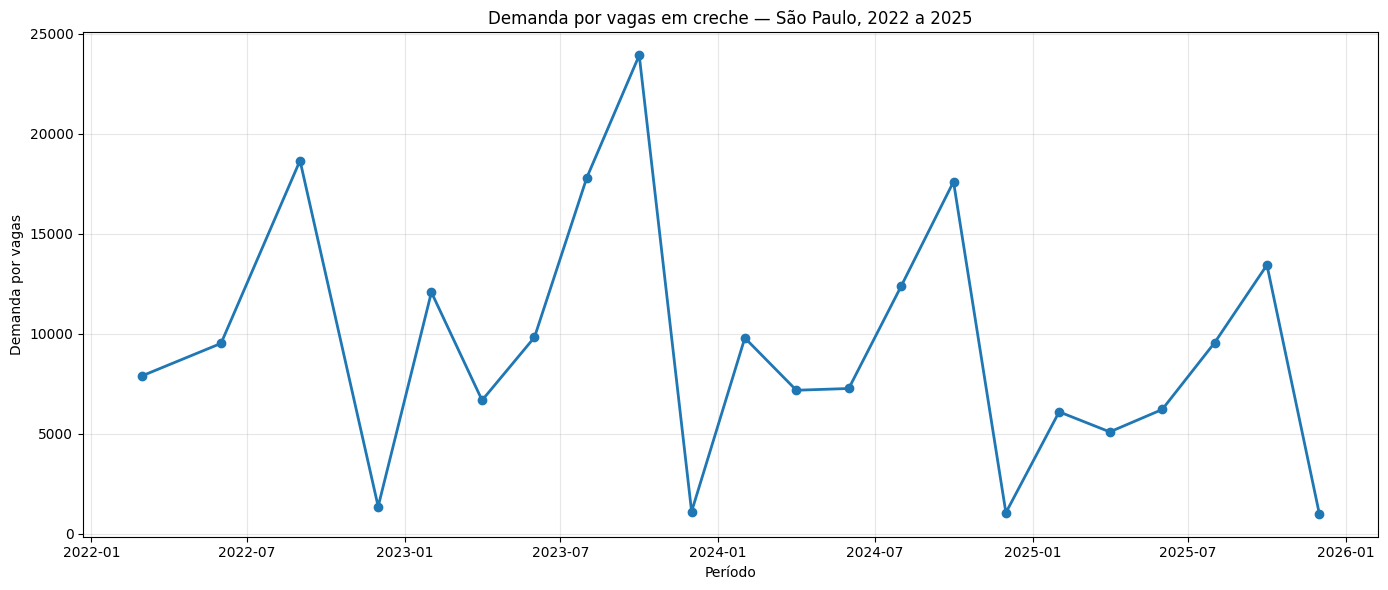

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    demanda_periodo["data"],
    demanda_periodo["demanda_creche"],
    marker="o",
    linewidth=2
)

plt.title("Demanda por vagas em creche — São Paulo, 2022 a 2025")
plt.xlabel("Período")
plt.ylabel("Demanda por vagas")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [36]:
comparacao_mensal = (
    demanda_periodo
    .pivot(
        index="mes",
        columns="ano",
        values="demanda_creche"
    )
)

comparacao_mensal


ano,2022,2023,2024,2025
mes,,,,
2,NaN,12078.0,9794.0,6098.0
3,7898.0,NaN,NaN,NaN
4,NaN,6676.0,7178.0,5096.0
6,9522.0,9826.0,7266.0,6216.0
8,NaN,17814.0,12380.0,9552.0
9,18664.0,NaN,NaN,NaN
10,NaN,23930.0,17606.0,13442.0
12,1362.0,1110.0,1056.0,1000.0


In [37]:
comparacao_mensal["variacao_2023_2025_%"] = (
    (comparacao_mensal[2025] - comparacao_mensal[2023])
    / comparacao_mensal[2023]
    * 100
)

comparacao_mensal


ano,2022,2023,2024,2025,variacao_2023_2025_%
mes,,,,,
2,NaN,12078.0,9794.0,6098.0,-49.511509
3,7898.0,NaN,NaN,NaN,NaN
4,NaN,6676.0,7178.0,5096.0,-23.666866
6,9522.0,9826.0,7266.0,6216.0,-36.739263
8,NaN,17814.0,12380.0,9552.0,-46.379252
9,18664.0,NaN,NaN,NaN,NaN
10,NaN,23930.0,17606.0,13442.0,-43.827831
12,1362.0,1110.0,1056.0,1000.0,-9.909910


In [38]:
meses_comparaveis = comparacao_mensal.dropna(
    subset=[2023, 2025]
).copy()

total_2023 = meses_comparaveis[2023].sum()
total_2025 = meses_comparaveis[2025].sum()

reducao_absoluta = total_2023 - total_2025

reducao_percentual = (
    reducao_absoluta / total_2023 * 100
)

print(f"Demanda nos meses comparáveis de 2023: {total_2023:,.0f}")
print(f"Demanda nos meses comparáveis de 2025: {total_2025:,.0f}")
print(f"Redução absoluta: {reducao_absoluta:,.0f}")
print(f"Redução percentual: {reducao_percentual:.1f}%")


Demanda nos meses comparáveis de 2023: 71,434
Demanda nos meses comparáveis de 2025: 41,404
Redução absoluta: 30,030
Redução percentual: 42.0%


In [39]:
matriculas_periodo = (
    df_final
    .groupby(["ano", "mes"], as_index=False)
    ["matriculas_creche"]
    .sum()
    .sort_values(["ano", "mes"])
)

matriculas_periodo


,ano,mes,matriculas_creche
0,2022,3,696942
1,2022,6,697950
2,2022,9,716086
3,2022,12,722514
4,2023,2,644054
5,2023,4,666234
6,2023,6,677572
7,2023,8,694366
8,2023,10,705188
9,2023,12,708186


In [40]:
analise = pd.merge(
    demanda_periodo[["ano", "mes", "demanda_creche"]],
    matriculas_periodo[["ano", "mes", "matriculas_creche"]],
    on=["ano", "mes"],
    how="inner"
)

analise


,ano,mes,demanda_creche,matriculas_creche
0,2022,3,7898,696942
1,2022,6,9522,697950
2,2022,9,18664,716086
3,2022,12,1362,722514
4,2023,2,12078,644054
5,2023,4,6676,666234
6,2023,6,9826,677572
7,2023,8,17814,694366
8,2023,10,23930,705188
9,2023,12,1110,708186


In [41]:
analise["demanda_sobre_matriculas_%"] = (
    analise["demanda_creche"]
    / analise["matriculas_creche"]
    * 100
)

analise


,ano,mes,demanda_creche,matriculas_creche,demanda_sobre_matriculas_%
0,2022,3,7898,696942,1.133236
1,2022,6,9522,697950,1.364281
2,2022,9,18664,716086,2.606391
3,2022,12,1362,722514,0.188508
4,2023,2,12078,644054,1.875309
5,2023,4,6676,666234,1.002050
6,2023,6,9826,677572,1.450178
7,2023,8,17814,694366,2.565506
8,2023,10,23930,705188,3.393421
9,2023,12,1110,708186,0.156738


In [42]:
meses_comparaveis = analise[
    analise["mes"].isin([2, 4, 6, 8, 10, 12])
].copy()

resultado_2023 = meses_comparaveis[
    meses_comparaveis["ano"] == 2023
]

resultado_2025 = meses_comparaveis[
    meses_comparaveis["ano"] == 2025
]

demanda_2023 = resultado_2023["demanda_creche"].sum()
matriculas_2023 = resultado_2023["matriculas_creche"].sum()

demanda_2025 = resultado_2025["demanda_creche"].sum()
matriculas_2025 = resultado_2025["matriculas_creche"].sum()

taxa_2023 = demanda_2023 / matriculas_2023 * 100
taxa_2025 = demanda_2025 / matriculas_2025 * 100

print(f"2023 — demanda: {demanda_2023:,.0f}")
print(f"2023 — matrículas: {matriculas_2023:,.0f}")
print(f"2023 — demanda/matrículas: {taxa_2023:.2f}%")
print()
print(f"2025 — demanda: {demanda_2025:,.0f}")
print(f"2025 — matrículas: {matriculas_2025:,.0f}")
print(f"2025 — demanda/matrículas: {taxa_2025:.2f}%")
print()
print(f"Variação do indicador: {((taxa_2025/taxa_2023)-1)*100:.1f}%")

2023 — demanda: 71,434
2023 — matrículas: 4,095,600
2023 — demanda/matrículas: 1.74%

2025 — demanda: 41,404
2025 — matrículas: 3,829,830
2025 — demanda/matrículas: 1.08%

Variação do indicador: -38.0%


Primeira versão dos resultados

In [43]:
resultado_principal = pd.DataFrame({
    "indicador": [
        "Demanda registrada",
        "Matrículas",
        "Demanda sobre matrículas"
    ],
    "2023": [
        demanda_2023,
        matriculas_2023,
        taxa_2023
    ],
    "2025": [
        demanda_2025,
        matriculas_2025,
        taxa_2025
    ],
    "variacao_percentual": [
        (demanda_2025 / demanda_2023 - 1) * 100,
        (matriculas_2025 / matriculas_2023 - 1) * 100,
        (taxa_2025 / taxa_2023 - 1) * 100
    ]
})

resultado_principal


,indicador,2023,2025,variacao_percentual
0,Demanda registrada,7.143400e+04,4.140400e+04,-42.038805
1,Matrículas,4.095600e+06,3.829830e+06,-6.489159
2,Demanda sobre matrículas,1.744164e+00,1.081092e+00,-38.016604


In [44]:
analise.to_csv(
    "demanda_creche_2022_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo criado com sucesso.")


Arquivo criado com sucesso.


In [45]:
from google.colab import files

files.download("demanda_creche_2022_2025.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
grafico_demanda = comparacao_mensal[
    [2023, 2024, 2025]
].reset_index()

grafico_demanda


ano,mes,2023,2024,2025
0,2,12078.0,9794.0,6098.0
1,3,NaN,NaN,NaN
2,4,6676.0,7178.0,5096.0
3,6,9826.0,7266.0,6216.0
4,8,17814.0,12380.0,9552.0
5,9,NaN,NaN,NaN
6,10,23930.0,17606.0,13442.0
7,12,1110.0,1056.0,1000.0


In [47]:
grafico_demanda = comparacao_mensal[
    [2023, 2024, 2025]
].dropna().reset_index()

grafico_demanda


ano,mes,2023,2024,2025
0,2,12078.0,9794.0,6098.0
1,4,6676.0,7178.0,5096.0
2,6,9826.0,7266.0,6216.0
3,8,17814.0,12380.0,9552.0
4,10,23930.0,17606.0,13442.0
5,12,1110.0,1056.0,1000.0


In [48]:
grafico_demanda.to_csv(
    "grafico_demanda_2023_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo do gráfico criado com sucesso.")

Arquivo do gráfico criado com sucesso.


In [49]:
from google.colab import files

files.download("grafico_demanda_2023_2025.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>